# Лабораторна робота №4 “Класифікація”
## Мета
Ознайомитися з основами класифікації при інтелектуальному аналізі даних на прикладі реального історичного набору даних Titanic.
Навчитись будувати класифікатор на основі дерев рішень (Decision Tree), виконувати попередню обробку даних, навчати модель, оцінювати якість класифікації за допомогою стандартних метрик та інтерпретувати отримані результати

#### 1. Завантаження та попередня обробка даних


1. Викачати датасет Titanic із Kaggle.
2. Завантажити файл train.csv у DataFrame.
3. Вивести загальну інформацію про дані, перевірити наявність пропущених значень.


In [28]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [30]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

4. Заповнити пропущені значення.

In [31]:
# Age — заповнюємо медіаною
df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked — найчастішим значенням
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin — видаляємо (занадто багато пропусків)
df = df.drop(columns=['Cabin'])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


5. Перетворити категоріальні ознаки у числовий формат.

In [32]:
# Sex → 0 / 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Embarked → one-hot encoding
df = pd.get_dummies(df, columns=['Embarked'])
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)
df['Embarked_C'] = df['Embarked_C'].astype(int)
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_C  891 non-null    int64  
 8   Embarked_Q  891 non-null    int64  
 9   Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 69.7 KB


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


Поділ даних на навчальну та тестову вибірки
Виконати поділ даних на train/test.
Вивести розміри навчальної та тестової вибірок.


#### 2. Поділ даних на навчальну та тестову вибірки
1. Виконати поділ даних на train/test.
2. Вивести розміри навчальної та тестової вибірок.


In [33]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Розмір X_train:", X_train.shape)
print("Розмір X_test:", X_test.shape)
print("Розмір y_train:", y_train.shape)
print("Розмір y_test:", y_test.shape)

Розмір X_train: (712, 9)
Розмір X_test: (179, 9)
Розмір y_train: (712,)
Розмір y_test: (179,)


#### 3. Побудова класифікатора на основі дерев рішень
1. Навчити модель дерева рішень на навчальних даних.
2. Отримати класифікацію для тестової вибірки.
3. Проаналізувати глибину дерева та кількість вузлів.


In [34]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42,
    max_depth=6
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

print("Глибина дерева:", tree_model.get_depth())
print("Кількість вузлів:", tree_model.tree_.node_count)

Глибина дерева: 6
Кількість вузлів: 67


#### 4. Оцінювання якості класифікації
1. Обчислити основні метрики класифікації:


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

Accuracy: 0.8045
Precision: 0.8421
Recall: 0.6486
F1-score: 0.7328


Отримані значення говорять про те, що модель демонструє достатньо високу загальну точність (Accuracy = 0.80) та високу точність передбачень класу виживання (Precision = 0.84). Проте значення Recall = 0.65 вказує на те, що модель пропускає частину пасажирів, які фактично вижили. Значення F1-score = 0.73 свідчить про помірний баланс між точністю та повнотою класифікації.

2. Побудувати confusion matrix.


Confusion Matrix:
[[96  9]
 [26 48]]


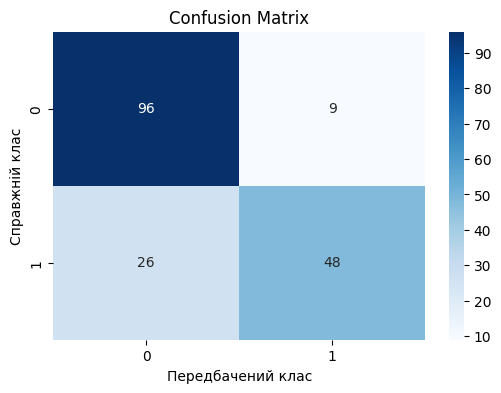

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Передбачений клас')
plt.ylabel('Справжній клас')
plt.title('Confusion Matrix')
plt.show()

3. Вивести детальний звіт класифікації (classification_report)

In [37]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       105
           1       0.84      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179



4. Проаналізувати баланс класів та пояснити, які метрики є більш інформативними для цього завдання.

In [38]:
print("Кількість об'єктів у класах:")
print(df['Survived'].value_counts())

print("\nУ відсотках:")
print(df['Survived'].value_counts(normalize=True) * 100)

Кількість об'єктів у класах:
Survived
0    549
1    342
Name: count, dtype: int64

У відсотках:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


#### 5. Інтерпретація моделі
1. Вивести важливість ознак (feature importance), отриману з дерева рішень.

In [39]:
feature_importance = pd.Series(tree_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
feature_importance

Sex           0.504436
Pclass        0.174494
Fare          0.153333
Age           0.097644
SibSp         0.045227
Parch         0.012770
Embarked_S    0.012097
Embarked_C    0.000000
Embarked_Q    0.000000
dtype: float64

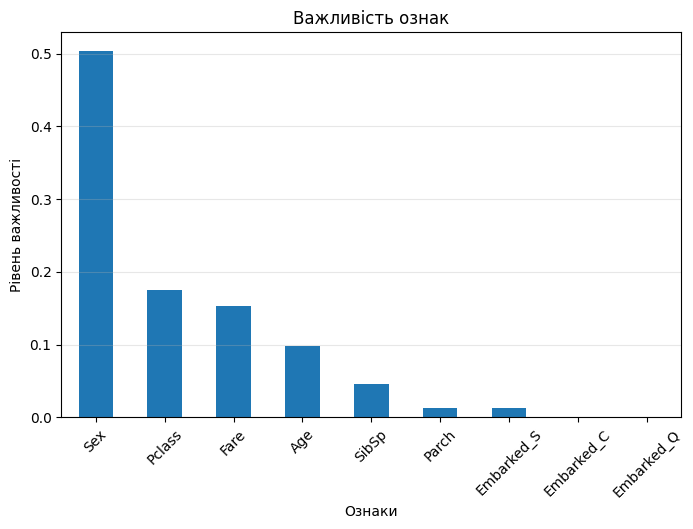

In [40]:
plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar')
plt.title('Важливість ознак')
plt.xlabel('Ознаки')
plt.ylabel('Рівень важливості')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

2. Проаналізувати, які характеристики пасажирів найбільше впливають на ймовірність виживання.


In [41]:
print("Найважливіші ознаки:")
print(feature_importance.head(5))

Найважливіші ознаки:
Sex       0.504436
Pclass    0.174494
Fare      0.153333
Age       0.097644
SibSp     0.045227
dtype: float64


Найбільший вплив має Sex (0.50), що пояснюється правилом евакуації “жінки і діти першими”, тому жінки мали значно вищі шанси вижити.

Ознака Pclass (0.17) є важливою, оскільки пасажири 1 класу мали кращий доступ до шлюпок і фізично знаходилися ближче до палуб.

Fare (0.15) також впливає, бо пов’язана із класом і соціальним статусом пасажира.

Age (0.10) має значення через пріоритет порятунку дітей.

Інші ознаки (SibSp, Parch, Embarked) мають низьку важливість, оскільки не визначають напряму можливість евакуації.

3. Візуалізувати дерево рішень.

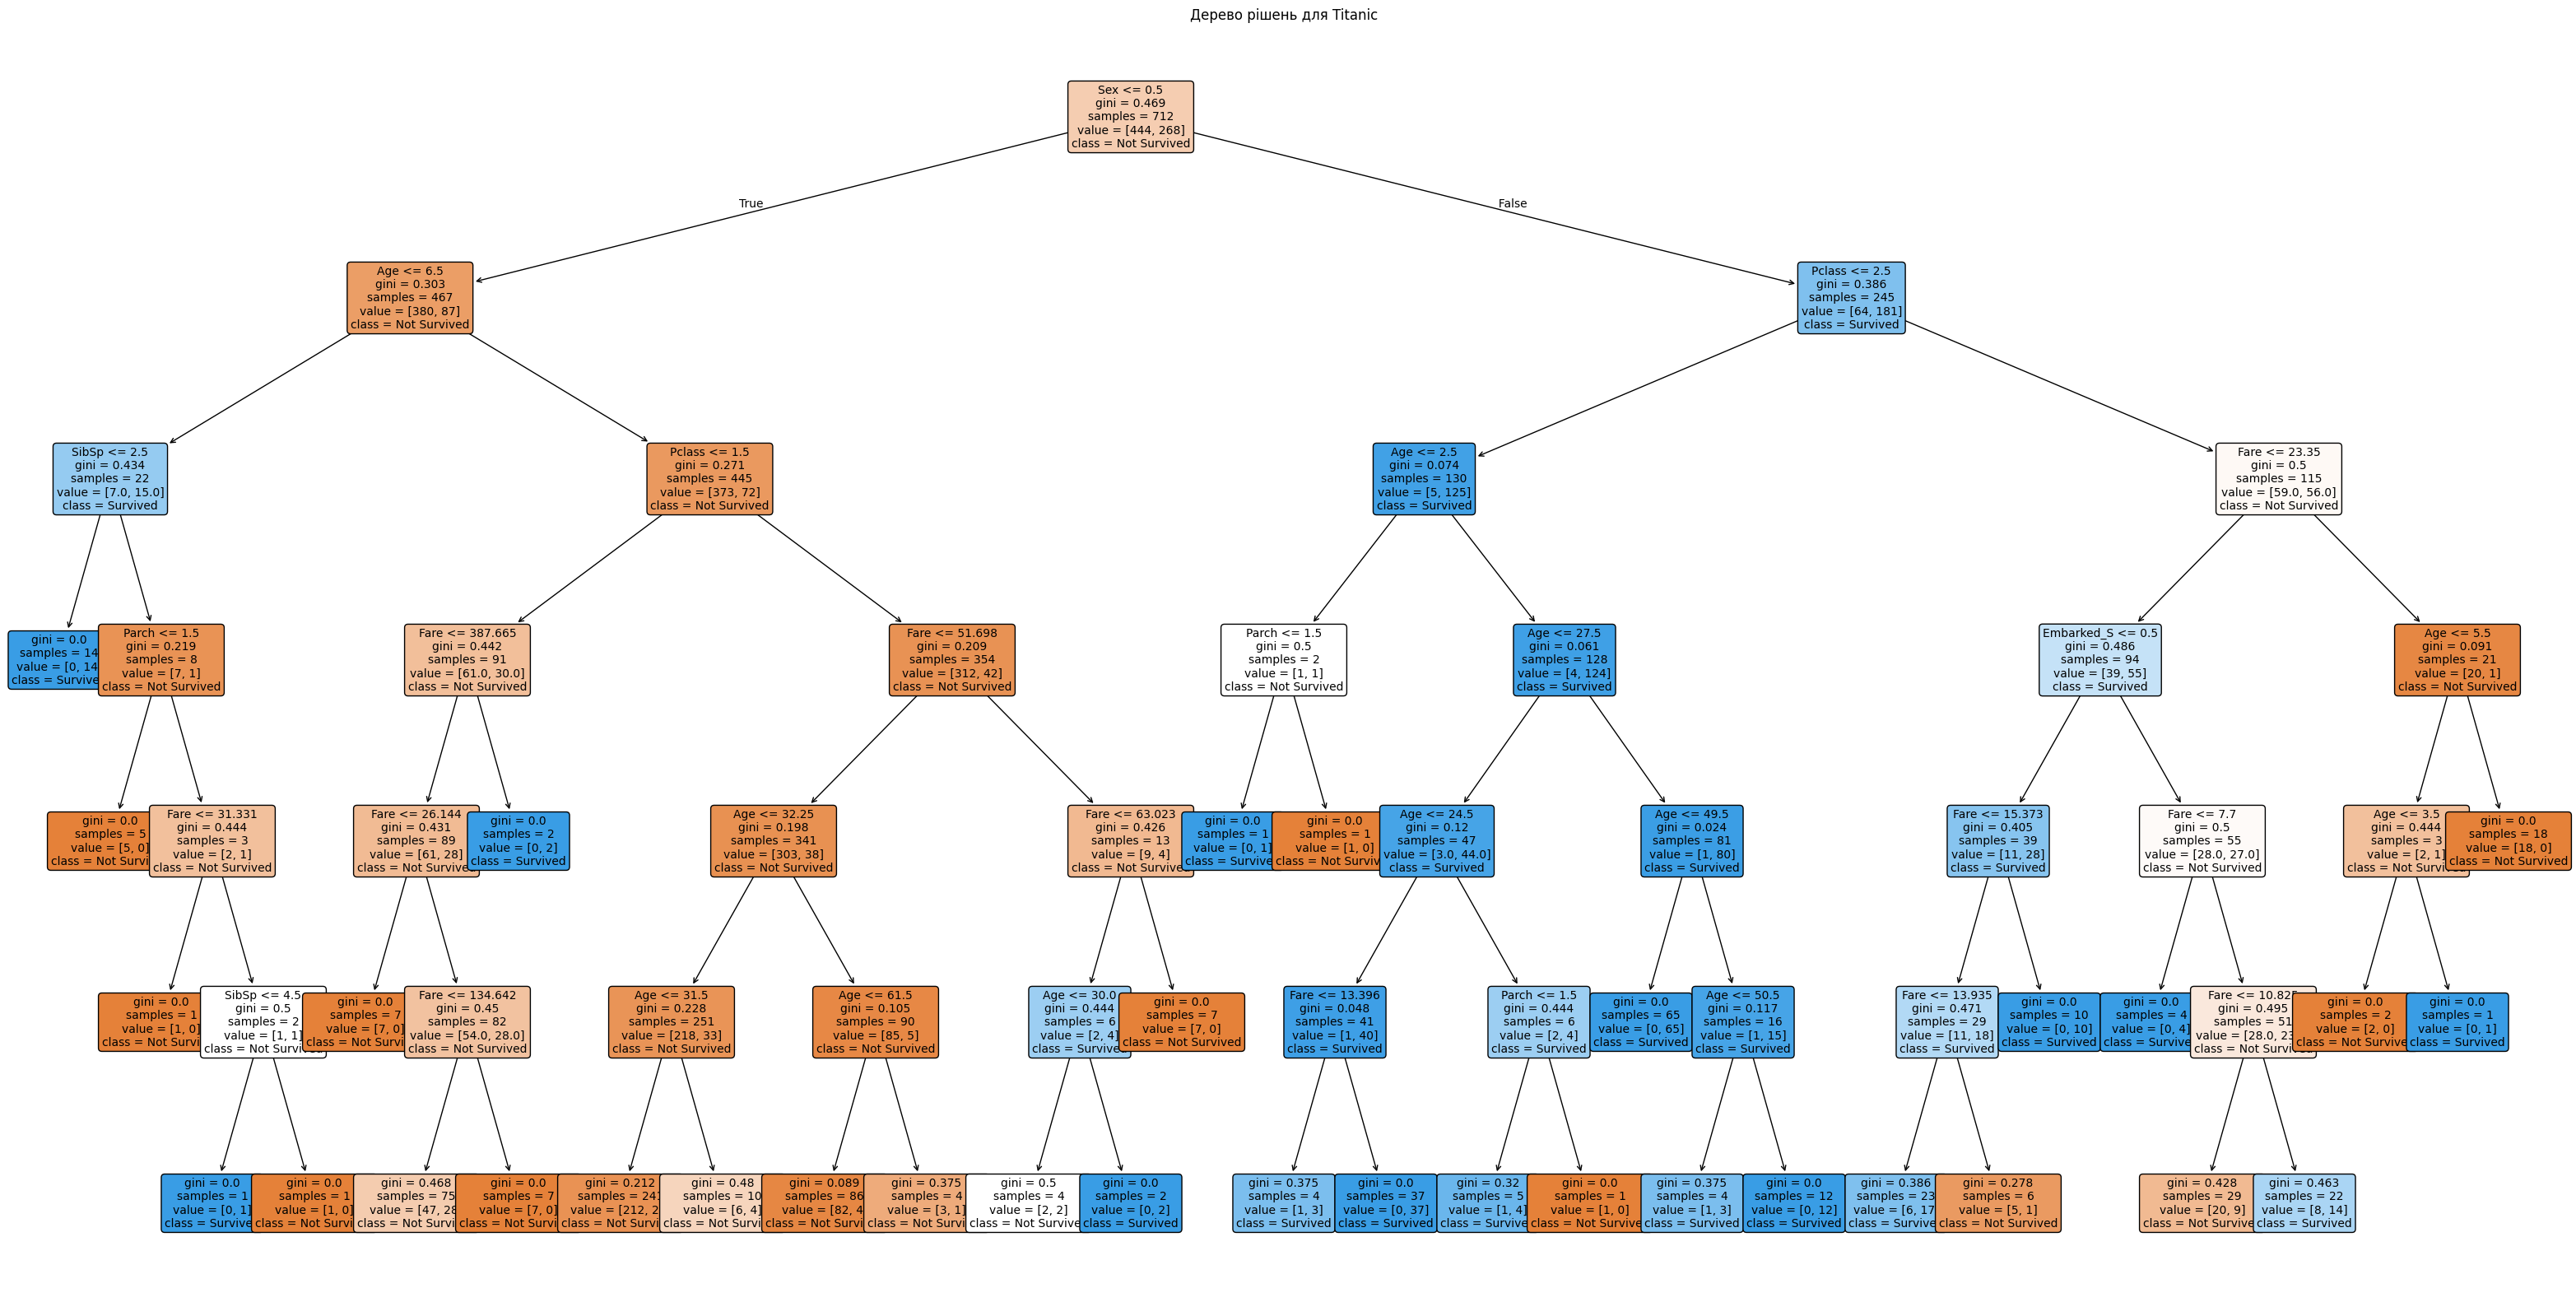

In [42]:
from sklearn.tree import plot_tree
plt.figure(figsize=(40, 20))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Дерево рішень для Titanic')
plt.show()

### Висновок

У роботі було побудовано модель класифікації на основі дерева рішень для прогнозування виживання пасажирів Titanic. Проведено підготовку даних, навчання моделі та оцінювання її якості за основними метриками.

Отримані результати показали задовільну точність моделі, а аналіз важливості ознак дозволив визначити ключові фактори, що впливають на виживання, зокрема стать, клас каюти, вартість квитка та вік.